In [1]:
from ultralytics import YOLO

model = YOLO("best.pt")

In [2]:
results = model.predict(
    source="car.jpg",
    device="cpu"
)


image 1/1 c:\Users\chumi\Desktop\license_OCR\car.jpg: 352x640 1 License_Plate, 470.6ms
Speed: 17.3ms preprocess, 470.6ms inference, 24.8ms postprocess per image at shape (1, 3, 352, 640)


In [3]:
results = model("car.jpg", device="cpu")


image 1/1 c:\Users\chumi\Desktop\license_OCR\car.jpg: 352x640 1 License_Plate, 304.7ms
Speed: 6.4ms preprocess, 304.7ms inference, 2.1ms postprocess per image at shape (1, 3, 352, 640)


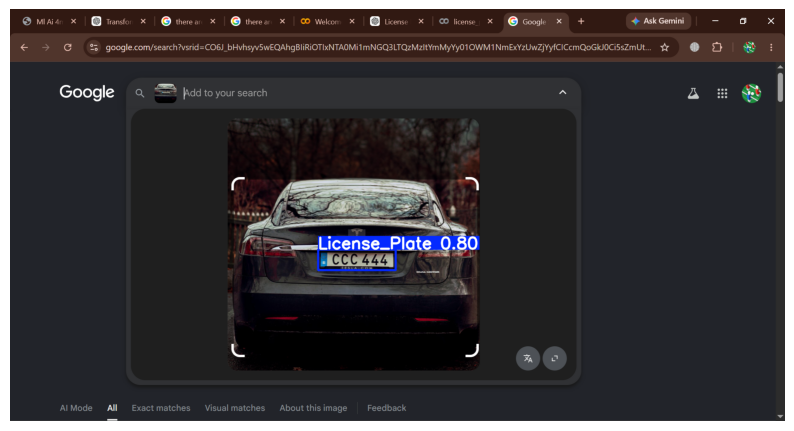

In [4]:
import matplotlib.pyplot as plt
annotated = results[0].plot()

# Convert BGR to RGB
annotated = annotated[:, :, ::-1]

# Display
plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [5]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO


0: 352x640 1 License_Plate, 565.7ms
Speed: 53.6ms preprocess, 565.7ms inference, 36.4ms postprocess per image at shape (1, 3, 352, 640)


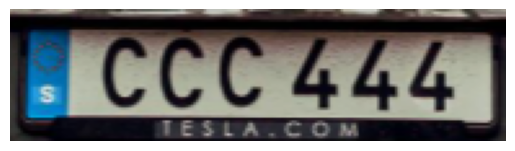

In [22]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load model
model = YOLO("best.pt")

# Read image
image = cv2.imread("car.jpg")

# Detect
results = model(image)

# Get first detection
for box in results[0].boxes:

# Bounding box coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])

# Crop the plate
    plate = image[y1:y2, x1:x2]

# Save cropped plate
cv2.imwrite("cropped_plate.jpg", plate)

# Show cropped plate
plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [23]:
import cv2

img = cv2.imread("cropped_plate.jpg")

print(img.shape)

(51, 192, 3)


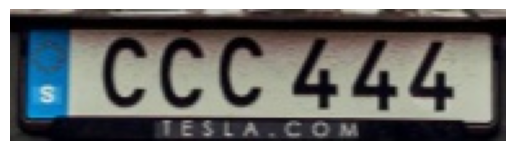

In [24]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [25]:
import easyocr

print(easyocr.__version__)

1.7.2


In [26]:
print(img.shape)

(51, 192, 3)


In [27]:
import cv2
import easyocr

reader = easyocr.Reader(['en'])

img = cv2.imread("cropped_plate.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

result = reader.readtext(gray)

print(result)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[([[np.int32(29), np.int32(5)], [np.int32(177), np.int32(5)], [np.int32(177), np.int32(45)], [np.int32(29), np.int32(45)]], 'CCC 444', np.float64(0.42869277614595447))]


In [28]:
import cv2

img = cv2.imread("cropped_plate.jpg")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Upscale 3x
gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

# Reduce noise
gray = cv2.GaussianBlur(gray, (3,3), 0)

# Threshold
gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

cv2.imwrite("processed_plate.jpg", gray)

True

In [29]:
import cv2

img = cv2.imread("processed_plate.jpg", cv2.IMREAD_UNCHANGED)

print(img.shape)
print(img.dtype)

(153, 576, 1)
uint8


In [30]:
img = img.squeeze()   # Remove the extra channel

print(img.shape)      # Should be (153, 576)

result = reader.readtext(img)
print(result)

(153, 576)
[([[np.int32(87), np.int32(21)], [np.int32(539), np.int32(21)], [np.int32(539), np.int32(129)], [np.int32(87), np.int32(129)]], 'CcC 444', np.float64(0.48947493746101356)), ([[np.int32(172), np.int32(124)], [np.int32(406), np.int32(124)], [np.int32(406), np.int32(152)], [np.int32(172), np.int32(152)]], 'TEs[^ Co m', np.float64(0.0431507997711508))]


In [31]:
result = reader.readtext(
    img,
    allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
)

In [33]:
if len(result) > 0:
    plate_text = result[0][1]
    print("Detected Plate:", plate_text)
else:
    plate_text = ""
    print("No text detected")

Detected Plate: CCC444


In [34]:
import re
plate_text = re.sub(r'[^A-Z0-9]', '', plate_text.upper())

In [35]:
print("Cleaned Plate:", plate_text)

Cleaned Plate: CCC444
